In [32]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using DifferentialEquations

In [7]:
ω0_resonance = 1.2
ω1_coupling = 1
function P(t,ω)
    Δ = ω0_resonance - ω
    Ωr = √((ω0_resonance - ω)^2 + ω1_coupling)
    front = ω1_coupling^2/Ωr^2 
    side = sin(Ωr * t/2) ^2
    return Δ, front * side
end


P (generic function with 1 method)

In [9]:
P(1,1.2)

(0.0, 0.22984884706593015)

In [ ]:
h = 6.626 #* 10**-34
ħ = h/(2*π)
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -im; im  0]
σz = ComplexF64[1 0; 0 -1]
function ham_raw(t,ω)
    H = ω0_resonance * ħ/2 * σz + ω1_coupling * (cos(ωt)*ħ/2 * σx +  sin(ωt)*ħ/2 * σy)
    return H
end
function ham_con(t,ω)
    H = ħ/2 * ComplexF64[ω0_resonance ω1_coupling*exp(-im*ω*t);
                        ω1_coupling*exp(im*ω*t) -ω0_resonance]
    return H
end

2×2 Matrix{ComplexF64}:
 0.632736+0.0im        0.284891-0.443691im
 0.284891+0.443691im  -0.632736+0.0im

In [16]:
srt = 1/(√(2))
c_plus = srt
c_minus = srt
state0 = [1;0]
state1 = [0;1]
plus_state = srt*state0 + srt * state1
minus_state = srt * state0 - srt * state1
function psi(t,ω)
    ψ̃ = c_plus * exp(im*ω*t/2) * plus_state + c_minus * exp(-im*ω*t)*minus_state
end

psi (generic function with 1 method)

In [92]:
ω0 =2π * 6 #* 10^9
ω = 2π * 6 #* 10^9
Ω = 2π * 0.2 #* 10^9
Δ = ω0 - ω

Heff = ħ*(-Δ/2 * σz + ω1/2 * σx)
function make_schrodinger(psi, p, t)
    c_plus = psi[1]
    c_minus = psi[2]
    c_dot_plus = im * Δ/2 * c_plus - im * Ω/2 * c_minus
    c_dot_minus = - im * Δ/2 * c_minus - im * Ω/2 * c_plus
    return [c_dot_plus,c_dot_minus]
end
t_span = (0,30.0)
psi_start = ComplexF64[1; 0]

prob = ODEProblem(make_schrodinger,psi_start , t_span)
sol = solve(prob, Tsit5(), saveat=range(t_span[1], t_span[2], length=1000), maxiters=1e7)

retcode: Success
Interpolation: 1st order linear
t: 1000-element Vector{Float64}:
  0.0
  0.03003003003003003
  0.06006006006006006
  0.09009009009009009
  0.12012012012012012
  0.15015015015015015
  0.18018018018018017
  0.21021021021021022
  0.24024024024024024
  0.2702702702702703
  ⋮
 29.75975975975976
 29.78978978978979
 29.81981981981982
 29.84984984984985
 29.87987987987988
 29.90990990990991
 29.93993993993994
 29.96996996996997
 30.0
u: 1000-element Vector{Vector{ComplexF64}}:
 [1.0 + 0.0im, 0.0 + 0.0im]
 [0.99982199656256 + 0.0im, 0.0 - 0.018867304784303658im]
 [0.9992880496614306 + 0.0im, 0.0 - 0.03772789315947547im]
 [0.998398349500948 + 0.0im, 0.0 - 0.05657505067113453im]
 [0.9971532126494761 + 0.0im, 0.0 - 0.0754020656712608im]
 [0.995553082191686 + 0.0im, 0.0 - 0.09420223633526936im]
 [0.9935985277517042 + 0.0im, 0.0 - 0.11296887113443921im]
 [0.9912902454956939 + 0.0im, 0.0 - 0.13169528909915248im]
 [0.9886290582578965 + 0.0im, 0.0 - 0.150374833805618im]
 [0.98561591426

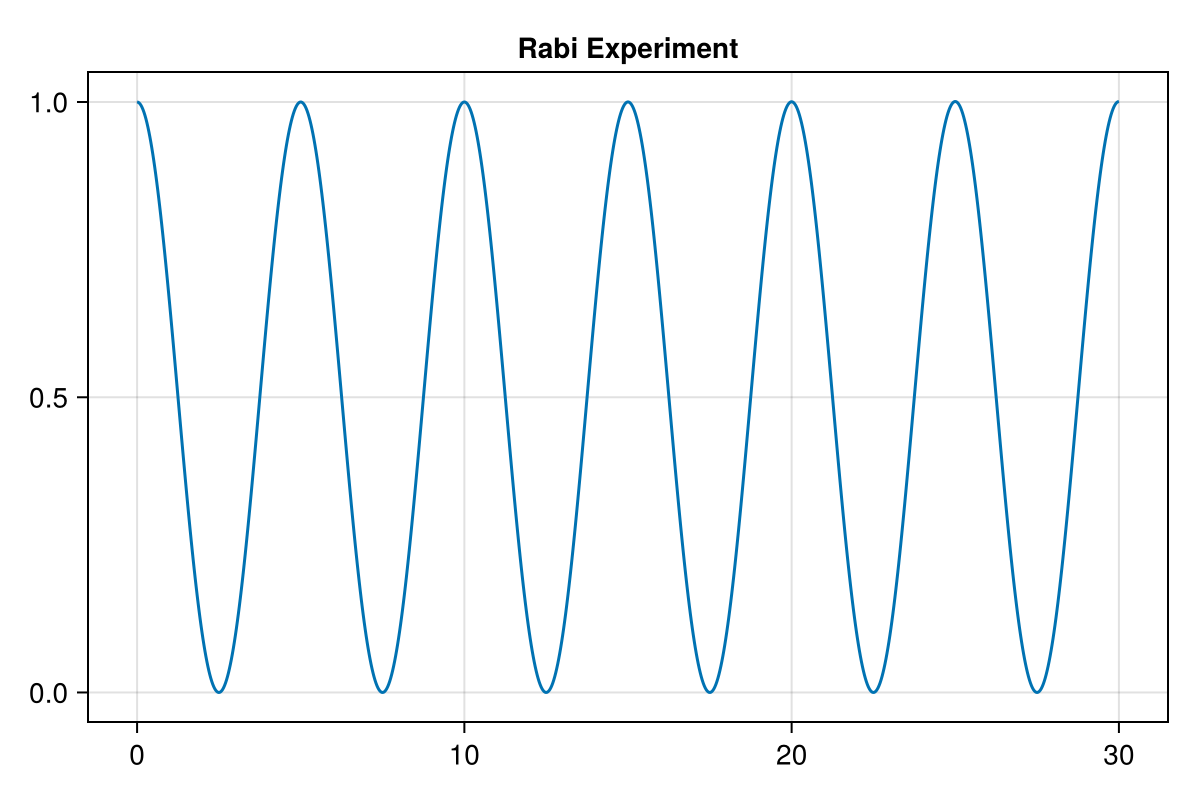

CairoMakie.Screen{IMAGE}


In [95]:
probs_plus = []
probs_minus = []

for i in sol.u
    push!(probs_plus, abs2(i[1]))
    push!(probs_minus, abs2(i[2]))
end
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Rabi Experiment")
lines!(ax, sol.t, probs_plus)

display(fig)


In [170]:
Ψ_origin = ComplexF64[0;1]
ρ_origin = Ψ_origin * Ψ_origin'

Δ = 0
Ω = 2π * 0.05

T1 = 100
T_ϕ = 50
γ1 = 1/T1
γ_ϕ = 1/T_ϕ

function linblad(ρ, p, t)
    H = ComplexF64[-Δ/2 Ω/2; Ω/2 Δ/2]
    front = -im * (H * ρ - ρ * H)
    L1 = ComplexF64[0 1; 0 0]
    L2 = ComplexF64[1 0; 0 -1]
    index_1 = L1 * ρ * L1' - 1/2 * (L1 * L1' * ρ + ρ * L1 * L1')
    index_2 = L2 * ρ * L2' - 1/2 * (L2 * L2' * ρ + ρ * L2 * L2')
    decoherence = γ1 * index_1 + γ_ϕ * index_2
    ρ̇ = front + decoherence
    return ρ̇
end

t_span = (0.0,100.0)
prob = ODEProblem(linblad, ρ_origin, t_span)
sol = solve(prob, Tsit5(), saveat=range(t_span[1], t_span[2], length=1000))
print("")

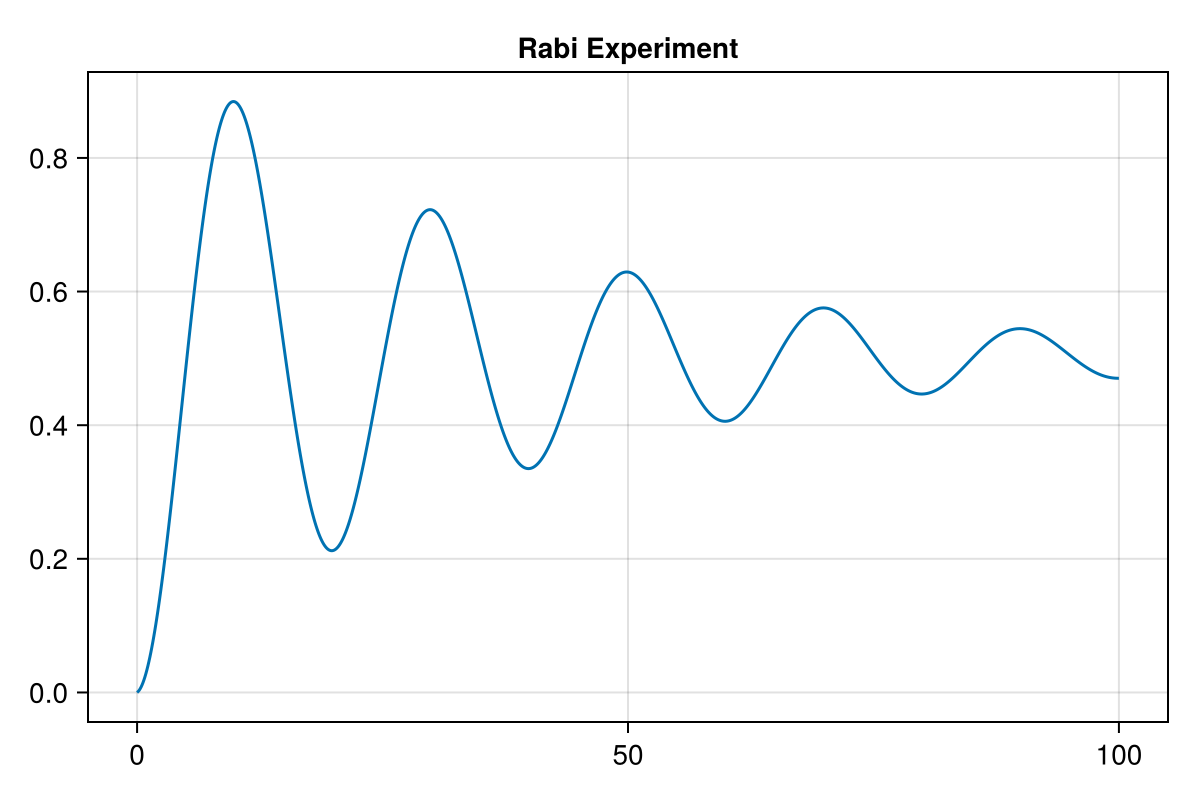

CairoMakie.Screen{IMAGE}


In [171]:
prob_zeroes = [] 
prob_ones = []

for i in range(1,length(sol.u))
    push!(prob_zeroes, real(sol.u[i][1]))
    push!(prob_ones, real(sol.u[i][4]))
end

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Rabi Experiment")
lines!(ax, sol.t, prob_zeroes)

display(fig)

In [235]:
function operate(Δ,Ω,T1,T_ϕ,t, chooser)
    
    function linblad(ρ, p, t)
        H = ComplexF64[-Δ/2 Ω/2; Ω/2 Δ/2]
        front = -im * (H * ρ - ρ * H)
        L1 = ComplexF64[0 1; 0 0]
        L2 = ComplexF64[1 0; 0 -1]
        index_1 = L1 * ρ * L1' - 1/2 * (L1 * L1' * ρ + ρ * L1 * L1')
        index_2 = L2 * ρ * L2' - 1/2 * (L2 * L2' * ρ + ρ * L2 * L2')
        decoherence = 1/T1 * index_1 + 1/T_ϕ * index_2
        ρ̇ = front + decoherence
        return ρ̇
    end

    t_span = (0.0,t)
    prob = ODEProblem(linblad, ρ_origin, t_span)
    sol = solve(prob, Tsit5(), saveat=range(t_span[1], t_span[2], length=1000))

    probs = []
    for i in range(1,length(sol.u))
        if chooser == 0
            push!(probs, real(sol.u[i][1]))
        else
            push!(probs, real(sol.u[i][4]))
        end
    end
    return probs, sol.t
end

operate (generic function with 1 method)

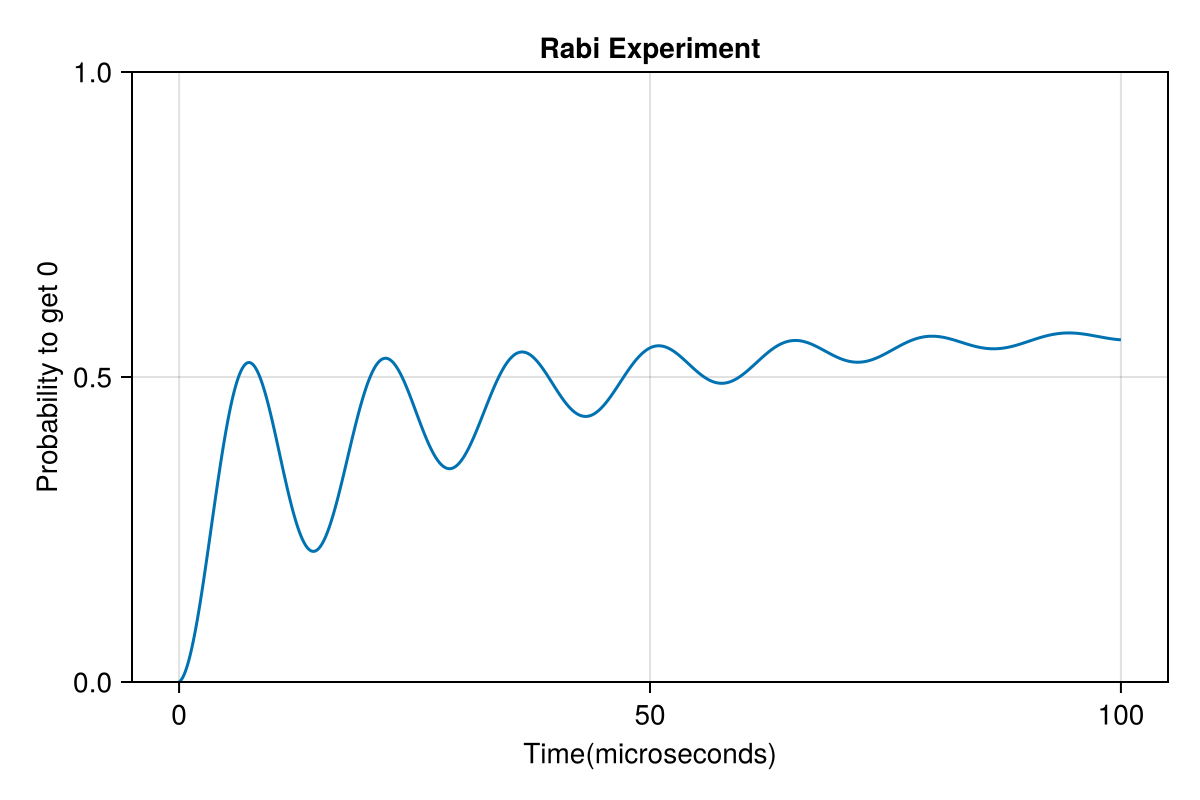

CairoMakie.Screen{IMAGE}


In [285]:
Δ = 0.3
Ω = 2π * 0.05
T1 = 100
T_ϕ = 50
t = 100
chooser = 0
o = operate(Δ,Ω, T1, T_ϕ,t,chooser)
fig = Figure(size = (600, 400))
ax = CairoMakie.Axis(fig[1, 1], title = "Rabi Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get $chooser")
lines!(ax, o[2],o[1])
ylims!(0,1)
display(fig)

In [287]:
using Images
clean = Float64.(o[1])
cart_indexes = findlocalmaxima(clean)
indices = [i[1] for i in cart_indexes]
deleteat!(indices, length(indices))
periods = []
for i in range(1, length(indices)-1)
    push!(periods, indices[i+1] - indices[i]) 
end
period = sum(period)/length(period)

Omega = 1/period
Ω_eff = sqrt(Omega^2 + Δ^2)
#P_max = Omega^2/Ω_eff^2 * 100

0.30004166377354996